# ECG Multi-class Classification on MIT-BIH Arrhythmia Database

**Course:** Artificial Intelligence in Medicine

**Authors:** Nicoletta Toma, Laura Tufo, Valentino Vacirca

---

## Narrative & Perspective

**Central question:** Can we build a deep learning system capable of accurately classifying heartbeat morphologies into specific clinical categories?

This is a **supervised multi-class classification** task. We aim to leverage professional cardiologist annotations to train models that recognize the specific 'signatures' of different arrhythmias.

Key challenges addressed in this project:
1. **Extreme Class Imbalance**: Some arrhythmias are thousands of times rarer than normal beats.
2. **Temporal Feature Extraction**: Capturing the intricate relationships between the P-wave, QRS complex, and T-wave.
3. **Modern Architectures**: Comparing traditional RNNs with state-of-the-art **Liquid Neural Networks (CfC)**.

---

## Model Strategy

We will explore architectures of increasing complexity to handle the sequential nature of ECG signals:

| Model | Type | Learning Paradigm |
|---|---|---|
| Random Forest | Baseline | Statistical features (Mean, Std, Skewness) |
| 1D-CNN | Deep Learning | Automated spatial feature extraction |
| Bi-LSTM | Deep Learning | Recurrent sequential dependencies |
| **Liquid NN (CfC)** | **SOTA** | **Closed-form Continuous-time neural networks** |

---

---
## 1. Setup and Data Loading

### 1.1 Dependencies

All standard scientific libraries (numpy, matplotlib, sklearn, torch) are already installed on Colab. We only need to install two additional packages:

- **`wfdb`**: official PhysioNet library for reading ECG records (`.dat` / `.hea` / `.atr` files).
- **`ncps`**: Neural Circuit Policies —> provides the **CfC (Liquid NN)** implementation.

### 1.1.1 Google Drive Mounting

In [1]:
from google.colab import drive
import os
import zipfile

drive.mount('/content/drive')

# Path to the dataset
DRIVE_PATH = '/content/drive/MyDrive/ECG_Project'
os.makedirs(DRIVE_PATH, exist_ok=True)

Mounted at /content/drive


In [2]:
!pip install wfdb ncps --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.3/60.3 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 118.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.


### 1.2 Imports and Global Settings

In [3]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter

import wfdb

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from scipy.signal import butter, filtfilt

import sys
import time

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# Segmentation constants
FS          = 360
HALF_WINDOW = 90
BEAT_LEN    = 2 * HALF_WINDOW

Using device: cuda


### Segmentation Logic

To transform the continuous ECG signal into a dataset suitable for classification, we apply a windowing process centered around the **R-peak** (provided by the clinical annotations):

1.  **Fixed-Width Windows**: For each annotated heartbeat, we extract a segment of signal surrounding the R-peak.
2.  **Window Parameters**: We use a `HALF_WINDOW` of 90 samples. At a sampling rate of 360 Hz, this captures 250ms before and 250ms after the peak, resulting in a total `BEAT_LEN` of 180 samples (approx. 500ms).
3.  **Signal Normalization**: Each extracted segment is typically Z-score normalized (zero mean, unit variance) to ensure that the model learns morphological patterns rather than absolute amplitude variations between different recordings.

This approach ensures that each input sample contains the full QRS complex and the immediate surrounding temporal context necessary for arrhythmia identification.

### 1.3 Download MIT-BIH from PhysioNet

The MIT-BIH Arrhythmia Database contains 48 two-channel ambulatory ECG recordings, each approximately 30 minutes long, sampled at **360 Hz**. Every beat is annotated with a symbol by trained cardiologists (e.g. `N` = normal sinus, `V` = premature ventricular contraction, `A` = atrial premature beat).

In [4]:
import zipfile

# Path
DATA_DIR = os.path.join(DRIVE_PATH, 'mitdb')
ZIP_PATH = '/content/mit-bih-arrhythmia-database-1.0.0.zip'

if not os.path.exists(DATA_DIR):
    if os.path.exists(ZIP_PATH):
        print(f"Extracting dataset from {ZIP_PATH}...")
        with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
            zip_ref.extractall(DRIVE_PATH)

        extracted_folder = os.path.join(DRIVE_PATH, 'mit-bih-arrhythmia-database-1.0.0')
        if os.path.exists(extracted_folder):
            os.rename(extracted_folder, DATA_DIR)
        print("Extraction completed.")
    else:
        print('Downloading from PhysioNet...')
        wfdb.dl_database('mitdb', DATA_DIR)
        print('Download completed.')
else:
    print(f'Dataset already present in {DATA_DIR}.')

# Complete list of 48 record IDs
ALL_RECORDS = [
    '100','101','102','103','104','105','106','107',
    '108','109','111','112','113','114','115','116',
    '117','118','119','121','122','123','124','200',
    '201','202','203','205','207','208','209','210',
    '212','213','214','215','217','219','220','221',
    '222','223','228','230','231','232','233','234'
]
print(f'Total records ready: {len(ALL_RECORDS)}')

Dataset already present in /content/drive/MyDrive/ECG_Project/mitdb.
Total records ready: 48


### 1.4 AAMI Mapping & Class Exclusion

To ensure clinical relevance and follow the **De Chazal (2004)** benchmark, we map MIT-BIH symbols into 4 primary AAMI categories.

**Exclusion of Class Q (Unknown):**
In this project, we explicitly exclude the 'Unknown' (Q) category. This is justified by two factors:
1. **Clinical Consistency**: Category Q often contains technical artifacts or unclassifiable beats that lack specific diagnostic value for arrhythmia classification.
2. **Statistical Insignificance**: After excluding paced-dominant records (as per De Chazal), the number of 'Q' beats drops to nearly zero (approx. 0.02%), making it impossible for models to learn this class effectively.

| AAMI Class | Description | MIT-BIH Symbols |
|---|---|---|
| **N** (Normal) | Normal beat, Left/Right bundle branch block | `N`, `L`, `R`, `e`, `j` |
| **S** (SVEB) | Supraventricular ectopic beat | `A`, `a`, `J`, `S` |
| **V** (VEB) | Ventricular ectopic beat | `V`, `E` |
| **F** (Fusion) | Fusion of ventricular and normal beat | `F` |

*Note: Symbols mapped to 'Other' or 'Unknown' are filtered out during the dataset creation phase.*

In [5]:
def get_aami_category(symbol):
    """Maps MIT-BIH symbols to AAMI categories, excluding Q (Unknown)."""
    mapping = {
        'N': 'Normal', 'L': 'Normal', 'R': 'Normal', 'e': 'Normal', 'j': 'Normal', # N
        'A': 'SVEB', 'a': 'SVEB', 'J': 'SVEB', 'S': 'SVEB',                         # S
        'V': 'VEB', 'E': 'VEB',                                                   # V
        'F': 'Fusion'                                                             # F
    }
    # Symbols like '/', 'f' (Paced) and 'Q' (Unknown) are treated as 'Excluded'
    return mapping.get(symbol, 'Excluded')

In [6]:
try:
    print(f"Clinical label distribution (Record 100):")
    counts = Counter([get_aami_category(s) for s in ann_symbols if get_aami_category(s) != 'Other'])
    for cat, count in counts.items():
        print(f" - {cat}: {count}")
except NameError:
    print("Note: Load a record first to see the distribution.")

Clinical label distribution (Record 100):
Note: Load a record first to see the distribution.


### 1.5 Train / Test Split: The De Chazal (2004) Standard

**Critical methodological choice: split by full records, not individual beats.**

Splitting at the beat level would allow segments from the same patient to appear in both training and testing sets, causing *data leakage*. To ensure academic rigor and comparability with state-of-the-art literature, we adopt the split proposed by **De Chazal et al. (2004)**.

This standard divides the MIT-BIH records into two independent sets (DS1 and DS2).

#### Exclusion of Paced-Dominant Records
Following this methodology, four records are explicitly excluded: **102, 104, 107, and 217**. These are omitted because they consist predominantly of paced beats, which the AAMI standard suggests evaluating separately to avoid interfering with spontaneous arrhythmia morphology.

| Set | Records (IDs) | Purpose |
|---|---|---|
| **DS1 (Train)** | 101, 106, 108, 109, 112, 114, 115, 116, 118, 119, 122, 124, 201, 203, 205, 207, 208, 209, 215, 220, 223, 230 | Model training and internal validation |
| **DS2 (Test)** | 100, 103, 105, 111, 113, 117, 121, 123, 200, 202, 210, 212, 213, 214, 219, 221, 222, 228, 231, 232, 233, 234 | Final independent evaluation |

By using this fixed partition, we ensure that the model is evaluated on entirely 'unseen' patients, providing a realistic estimate of its diagnostic performance in a clinical setting.

In [7]:
### Implementation of De Chazal (2004) Split
# DS1: Used for Training and Validation
DS1 = ['101', '106', '108', '109', '112', '114', '115', '116', '118', '119', '122', '124', '201', '203', '205', '207', '208', '209', '215', '220', '223', '230']

# DS2: Used for Testing
DS2 = ['100', '103', '105', '111', '113', '117', '121', '123', '200', '202', '210', '212', '213', '214', '219', '221', '222', '228', '231', '232', '233', '234']

# To maintain a validation set, we take the last 3 records of DS1
TRAIN_RECORDS = DS1[:-3]
VAL_RECORDS   = DS1[-3:]
TEST_RECORDS  = DS2

print(f'Train Records (from DS1): {len(TRAIN_RECORDS)}')
print(f'Val Records   (from DS1): {len(VAL_RECORDS)}')
print(f'Test Records  (DS2):      {len(TEST_RECORDS)}')
print(f'Total: {len(TRAIN_RECORDS) + len(VAL_RECORDS) + len(TEST_RECORDS)} records used (Excluding 102, 104, 107, 217)')

Train Records (from DS1): 19
Val Records   (from DS1): 3
Test Records  (DS2):      22
Total: 44 records used (Excluding 102, 104, 107, 217)


#### *Methodological Note: Why EDA on Training Set Only?*

We perform Exploratory Data Analysis exclusively on the **training records** to prevent **data leakage**. Analyzing the distribution or properties of the test set could inadvertently influence our design choices (e.g., how we handle class imbalance or normalize signals), leading to biased evaluations. To ensure a rigorous assessment of the model's generalization capabilities, the validation and test sets must remain 'unseen' during the discovery phase.

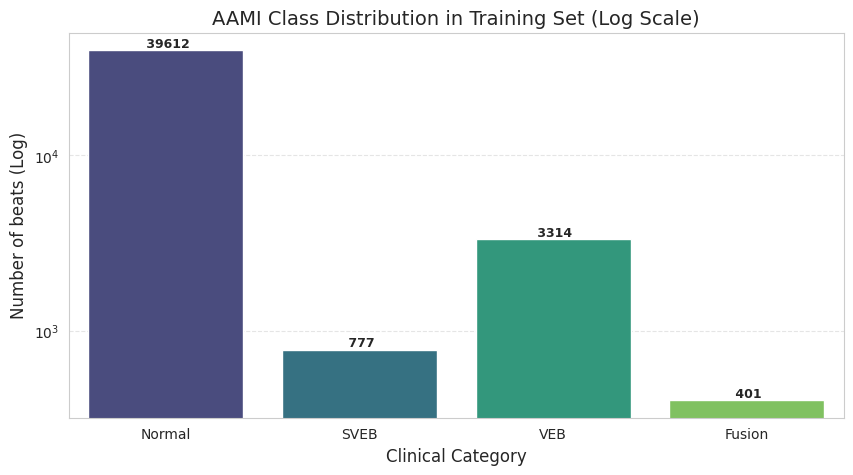

Summary statistics (Diagnostic Classes Only):
 - Normal  :  39612 beats (89.81%)
 - SVEB    :    777 beats ( 1.76%)
 - VEB     :   3314 beats ( 7.51%)
 - Fusion  :    401 beats ( 0.91%)


In [8]:
# Collect only the 4 diagnostic AAMI labels from training records for EDA
all_syms = []
for r in TRAIN_RECORDS:
    ann = wfdb.rdann(os.path.join(DATA_DIR, r), 'atr')
    all_syms.extend(ann.symbol)

# Filter out 'Excluded' (Paced/Unknown) to focus on the 4 target classes
aami_labels = [get_aami_category(s) for s in all_syms if get_aami_category(s) != 'Excluded']
counts = Counter(aami_labels)

# Order classes for consistency: N, S, V, F
ordered_classes = ['Normal', 'SVEB', 'VEB', 'Fusion']
values = [counts.get(cls, 0) for cls in ordered_classes]

plt.figure(figsize=(10, 5))
sns.set_style("whitegrid")

ax = sns.barplot(x=ordered_classes, y=values, hue=ordered_classes, palette='viridis', legend=False)
plt.yscale('log')
plt.title('AAMI Class Distribution in Training Set (Log Scale)', fontsize=14)
plt.ylabel('Number of beats (Log)', fontsize=12)
plt.xlabel('Clinical Category', fontsize=12)

# Add absolute counts on top of bars for clarity
for i, v in enumerate(values):
    ax.text(i, v, f' {v}', ha='center', va='bottom', fontsize=9, weight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

print("Summary statistics (Diagnostic Classes Only):")
for cls in ordered_classes:
    count = counts.get(cls, 0)
    perc = (count / len(aami_labels)) * 100
    print(f" - {cls:8}: {count:6} beats ({perc:5.2f}%)")

### 1.6 Quick Record Analysis

Let's visualize 10 seconds of raw signal from record 100. Annotations indicate the beat type according to the AAMI standard (e.g., 'N' for Normal, 'V' for VEB).

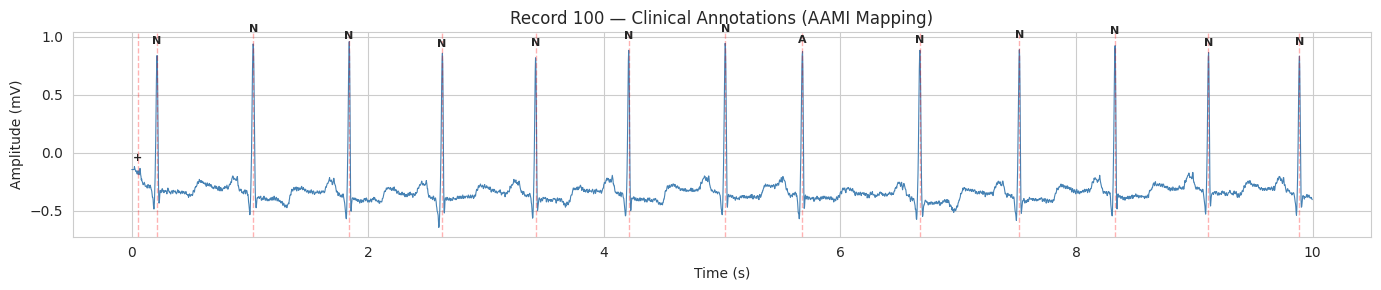

In [9]:
record     = wfdb.rdrecord(os.path.join(DATA_DIR, '100'))
annotation = wfdb.rdann(os.path.join(DATA_DIR, '100'), 'atr')

signal      = record.p_signal[:, 0]
ann_samples = annotation.sample
ann_symbols = np.array(annotation.symbol)

n_samples = 10 * FS
t         = np.arange(n_samples) / FS
mask      = ann_samples < n_samples

fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(t, signal[:n_samples], color='steelblue', lw=0.8, label='ECG signal')

for s, sym in zip(ann_samples[mask], ann_symbols[mask]):
    cat = get_aami_category(sym)
    if cat != 'Other':
        ax.axvline(s / FS, color='red', alpha=0.3, lw=1, linestyle='--')
        ax.text(s / FS, signal[s] + 0.1, sym, fontsize=8, weight='bold', ha='center')

ax.set(xlabel='Time (s)', ylabel='Amplitude (mV)',
       title='Record 100 — Clinical Annotations (AAMI Mapping)')
plt.tight_layout()
plt.show()

### 2.1 Beat Extraction and Processing

We define a function `load_records_filtered` that iterates through the MIT-BIH records and performs the following for each:

1. **Frequency Filtering**: Applies a Butterworth band-pass filter (0.5 – 45 Hz) to the entire signal to remove baseline wander and high-frequency noise.
2. **Peak-Centered Windowing**: For every annotated beat, it crops a segment of 180 samples (approx. 500ms) centered on the R-peak.
3. **Z-score Normalization**: Subtracts the mean and divides by the standard deviation of the individual segment to remove scale variations.
4. **Label Filtering**: Only keeps beats belonging to the 5 valid AAMI classes (Normal, SVEB, VEB, Fusion, Paced).

In [10]:
def bandpass_filter(data, lowcut=0.5, highcut=45.0, fs=360, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, data)
    return y

# Updated to 4-class mapping: Normal, SVEB, VEB, Fusion
def load_records_filtered(record_list):
    x_data = []
    y_data = []
    label_map = {'Normal': 0, 'SVEB': 1, 'VEB': 2, 'Fusion': 3}

    for record_id in record_list:
        path = os.path.join(DATA_DIR, record_id)
        record = wfdb.rdrecord(path)
        signal = bandpass_filter(record.p_signal[:, 0])

        annotation = wfdb.rdann(path, 'atr')
        peaks = annotation.sample
        symbols = annotation.symbol

        for i in range(len(peaks)):
            category = get_aami_category(symbols[i])
            if category in label_map:
                start, end = peaks[i] - HALF_WINDOW, peaks[i] + HALF_WINDOW
                if start > 0 and end < len(signal):
                    segment = signal[start:end]
                    segment = (segment - np.mean(segment)) / (np.std(segment) + 1e-8)
                    x_data.append(segment)
                    y_data.append(label_map[category])

    return np.array(x_data), np.array(y_data)

print("Filtered processing function synced to 4 classes.")

Filtered processing function synced to 4 classes.


### 2.2 Dataset Creation

Now, we apply the processing function to our split records (Train, Validation, and Test). This step may take a few moments as it processes thousands of heartbeats.

In [11]:
print("Extracting training segments (filtered)...\n")
X_train, y_train_raw = load_records_filtered(TRAIN_RECORDS)
X_val, y_val_raw = load_records_filtered(VAL_RECORDS)
X_test, y_test_raw = load_records_filtered(TEST_RECORDS)

# Updated labels mapping to 4 classes
inv_label_map = {0: 'Normal (N)', 1: 'SVEB (S)', 2: 'VEB (V)', 3: 'Fusion (F)'}

def print_clean_dist(y, title):
    counts = Counter([int(i) for i in y])
    print(f"{title} Distribution:")
    for label, count in sorted(counts.items()):
        print(f" - {inv_label_map[label]}: {count}")

print_clean_dist(y_train_raw, "Train")
print_clean_dist(y_val_raw, "Validation")
print_clean_dist(y_test_raw, "Test")

y_train, y_val, y_test = y_train_raw, y_val_raw, y_test_raw

Extracting training segments (filtered)...

Train Distribution:
 - Normal (N): 39604
 - SVEB (S): 777
 - VEB (V): 3314
 - Fusion (F): 400
Validation Distribution:
 - Normal (N): 6252
 - SVEB (S): 167
 - VEB (V): 474
 - Fusion (F): 14
Test Distribution:
 - Normal (N): 44246
 - SVEB (S): 1837
 - VEB (V): 3220
 - Fusion (F): 388


### 2.3 Final Preparation: Reshaping and Class Weights

Before moving to the models, we need to ensure the data is in the correct shape for Deep Learning (adding a channel dimension) and calculate weights to handle the significant class imbalance.

In [12]:
# 1. Reshape for CNN/RNN (N, Channels, Length)
X_train_dl = X_train[:, np.newaxis, :]
X_val_dl   = X_val[:, np.newaxis, :]
X_test_dl  = X_test[:, np.newaxis, :]

# 2. Calculate class weights for the Loss Function
unique_classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=unique_classes, y=y_train)
class_weights = torch.tensor(weights, dtype=torch.float).to(DEVICE)

print(f"Data reshaped for DL: {X_train_dl.shape}")
print(f"Computed class weights: {weights}")

Data reshaped for DL: (44095, 1, 180)
Computed class weights: [ 0.27834941 14.18758044  3.32641823 27.559375  ]


### 2.5 PyTorch DataLoaders & Training Utilities

We prepare the data for training by batching it and defining a loss function that accounts for the class imbalance using the weights computed previously.

In [13]:
BATCH_SIZE = 64

# Create TensorDatasets
train_dataset = TensorDataset(torch.Tensor(X_train_dl), torch.LongTensor(y_train))
val_dataset   = TensorDataset(torch.Tensor(X_val_dl), torch.LongTensor(y_val))
test_dataset  = TensorDataset(torch.Tensor(X_test_dl), torch.LongTensor(y_test))

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Define Weighted Loss Function
criterion = nn.CrossEntropyLoss(weight=class_weights)

print(f"DataLoaders created with Batch Size: {BATCH_SIZE}")
print("Weighted CrossEntropyLoss initialized.")

DataLoaders created with Batch Size: 64
Weighted CrossEntropyLoss initialized.


In [14]:
from tqdm.auto import tqdm

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=20):
    model.to(DEVICE)
    history = {'train_loss': [], 'val_loss': [], 'val_f1': []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        # Added tqdm progress bar for the training loop
        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False)

        for X_batch, y_batch in train_pbar:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            train_pbar.set_postfix({'loss': loss.item()})

        # Validation
        model.eval()
        val_loss = 0
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(y_batch.cpu().numpy())

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        f1 = f1_score(all_labels, all_preds, average='macro')

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_f1'].append(f1)

        print(f"Epoch [{epoch+1}/{epochs}] Summary - Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val F1: {f1:.4f}")

    return history

## 3. Baseline Model: Random Forest

# Description

In [15]:
results = {}   # useful for Pareto/deployment

In [16]:
from scipy.stats import skew, kurtosis

def extract_features(data):
    feats = []
    for i in range(len(data)):
        segment = data[i]
        feats.append([
            np.mean(segment),
            np.std(segment),
            skew(segment),
            kurtosis(segment),
            np.max(segment) - np.min(segment) # Peak-to-peak
        ])
    return np.array(feats)

print("Extracting features for Random Forest...")
X_train_rf = extract_features(X_train)
X_test_rf  = extract_features(X_test)

# Initialize and train RF
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=SEED, n_jobs=-1)
rf_model.fit(X_train_rf, y_train)

# Evaluation
y_pred_rf = rf_model.predict(X_test_rf)

print("\n--- Random Forest Baseline Report ---")
print(classification_report(y_test, y_pred_rf, target_names=[inv_label_map[i] for i in range(len(unique_classes))]))

Extracting features for Random Forest...

--- Random Forest Baseline Report ---
              precision    recall  f1-score   support

  Normal (N)       0.94      0.94      0.94     44246
    SVEB (S)       0.03      0.01      0.02      1837
     VEB (V)       0.68      0.73      0.71      3220
  Fusion (F)       0.01      0.03      0.02       388

    accuracy                           0.89     49691
   macro avg       0.42      0.43      0.42     49691
weighted avg       0.88      0.89      0.88     49691



In [17]:
# For Random Forest, 'params' is approximated by the size of the model object in memory
rf_size = sys.getsizeof(rf_model)

# Simple latency check for RF
t = time.perf_counter()
for _ in range(50): rf_model.predict(X_test_rf[:BATCH_SIZE])
lat_ms_rf = (time.perf_counter() - t) / 50 * 1000

results['Random Forest'] = {
    'macro_f1': f1_score(y_test, y_pred_rf, average='macro'),
    'params': rf_size,
    'lat_ms': lat_ms_rf
}
print(f"RF 'Size' proxy: {rf_size} bytes | Latency: {lat_ms_rf:.2f} ms/batch")

RF 'Size' proxy: 48 bytes | Latency: 31.76 ms/batch


## 5. Recurrent Neural Network: Bi-LSTM

Unlike CNNs, Recurrent Neural Networks (RNNs) are explicitly designed for sequence data. A **Bidirectional LSTM** is particularly effective for ECG signals because it analyzes the signal both forward and backward, allowing the model to understand the context of a peak based on what happens both before and after it (e.g., the relationship between the P-wave and the T-wave).

In [18]:
class ECG_BiLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, num_classes=4):
        super(ECG_BiLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # Bi-LSTM Layer
        # input shape: (batch, seq_len, input_size)
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, bidirectional=True, dropout=0.2)

        # Fully connected layer
        # hidden_size * 2 because it's bidirectional
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        # x is (batch, 1, 180) -> needs to be (batch, 180, 1) for LSTM
        x = x.permute(0, 2, 1)

        # Forward propagate LSTM
        out, _ = self.lstm(x)

        # Decode the hidden state of the last time step
        out = self.fc(out[:, -1, :])
        return out

# Initialize Bi-LSTM
lstm_model = ECG_BiLSTM(num_classes=len(unique_classes)).to(DEVICE)
optimizer_lstm = torch.optim.Adam(lstm_model.parameters(), lr=0.001)

print("Bi-LSTM Architecture:")
print(lstm_model)

Bi-LSTM Architecture:
ECG_BiLSTM(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
  (fc): Linear(in_features=128, out_features=4, bias=True)
)


In [19]:
n_params_lstm = sum(p.numel() for p in lstm_model.parameters())
print(f"Bi-LSTM Trainable params: {n_params_lstm:,}")

Bi-LSTM Trainable params: 134,148


In [20]:
# Train the Bi-LSTM
lstm_history = train_model(
    model=lstm_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_lstm,
    epochs=20
)

Epoch 1/20 [Train]:   0%|          | 0/689 [00:00<?, ?it/s]

Epoch [1/20] Summary - Train Loss: 1.1229 | Val Loss: 1.0529 | Val F1: 0.2348


Epoch 2/20 [Train]:   0%|          | 0/689 [00:00<?, ?it/s]

Epoch [2/20] Summary - Train Loss: 1.1350 | Val Loss: 1.2480 | Val F1: 0.2023


Epoch 3/20 [Train]:   0%|          | 0/689 [00:00<?, ?it/s]

...

Epoch [18/20] Summary - Train Loss: 0.6602 | Val Loss: 1.1561 | Val F1: 0.3867


Epoch 19/20 [Train]:   0%|          | 0/689 [00:00<?, ?it/s]

Epoch [19/20] Summary - Train Loss: 0.6056 | Val Loss: 0.7561 | Val F1: 0.5490


Epoch 20/20 [Train]:   0%|          | 0/689 [00:00<?, ?it/s]

Epoch [20/20] Summary - Train Loss: 0.5434 | Val Loss: 1.2880 | Val F1: 0.4093


In [21]:
lstm_model.eval()
y_pred_lstm, y_true_lstm = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        preds = torch.argmax(lstm_model(X_batch), dim=1)
        y_pred_lstm.extend(preds.cpu().numpy())
        y_true_lstm.extend(y_batch.numpy())

# Define target_names here to avoid NameError
target_names = [inv_label_map[i] for i in range(len(unique_classes))]

# Benchmarking Latency for Bi-LSTM
xb = next(iter(test_loader))[0].to(DEVICE)
with torch.no_grad():
    for _ in range(3): lstm_model(xb)
    t = time.perf_counter()
    for _ in range(50): lstm_model(xb)
    lat_ms_lstm = (time.perf_counter() - t) / 50 * 1000

results['Bi-LSTM'] = {
    'macro_f1': f1_score(y_true_lstm, y_pred_lstm, average='macro'),
    'params': n_params_lstm,
    'lat_ms': lat_ms_lstm
}

print("\n--- Bi-LSTM Evaluation Report ---")
print(classification_report(y_true_lstm, y_pred_lstm, target_names=target_names))


--- Bi-LSTM Evaluation Report ---
              precision    recall  f1-score   support

  Normal (N)       0.90      0.38      0.54     44246
    SVEB (S)       0.03      0.10      0.05      1837
     VEB (V)       0.18      0.81      0.30      3220
  Fusion (F)       0.00      0.02      0.00       388

    accuracy                           0.40     49691
   macro avg       0.28      0.33      0.22     49691
weighted avg       0.82      0.40      0.50     49691



## 6. Liquid Neural Networks: Closed-form Continuous-time (CfC)

Liquid Neural Networks represent the state-of-the-art in sequential modeling. Unlike standard RNNs, they are inspired by the biological neural networks of small organisms (like *C. elegans*). We use the **CfC (Closed-form Continuous-time)** implementation from the `ncps` library, which approximates the continuous-time dynamics of liquid cells without needing expensive ODE solvers.

In [22]:
from ncps.torch import CfC
from ncps.wirings import AutoNCP

class ECG_LiquidNN(nn.Module):
    def __init__(self, input_size=1, units=64, num_classes=4):
        super(ECG_LiquidNN, self).__init__()

        # NCP wiring: sparse, structured connectivity.
        # 'units' = total neurons; the last 'num_classes' are the motor (output) neurons.
        wiring = AutoNCP(units, num_classes)

        # CfC built ON the wiring (not dense)
        self.rnn = CfC(input_size, wiring, batch_first=True)
        # NB: no separate fc layer — the motor neurons ARE the outputs

    def forward(self, x):
        x = x.permute(0, 2, 1)          # (batch, 1, 180) -> (batch, 180, 1)
        out, _ = self.rnn(x)            # out last-dim == num_classes
        return out[:, -1, :]            # last time step -> (batch, num_classes)

liquid_model = ECG_LiquidNN(num_classes=len(unique_classes)).to(DEVICE)
optimizer_liquid = torch.optim.Adam(liquid_model.parameters(), lr=0.001)

n_params_liquid = sum(p.numel() for p in liquid_model.parameters())
print("Liquid NN (CfC + AutoNCP) Architecture:")
print(liquid_model)
print(f"Trainable params: {n_params_liquid:,}")

Liquid NN (CfC + AutoNCP) Architecture:
ECG_LiquidNN(
  (rnn): CfC(
    (rnn_cell): WiredCfCCell(
      (layer_0): CfCCell(
        (tanh): Tanh()
        (sigmoid): Sigmoid()
        (ff1): Linear(in_features=37, out_features=36, bias=True)
        (ff2): Linear(in_features=37, out_features=36, bias=True)
        (time_a): Linear(in_features=37, out_features=36, bias=True)
        (time_b): Linear(in_features=37, out_features=36, bias=True)
      )
      (layer_1): CfCCell(
        (tanh): Tanh()
        (sigmoid): Sigmoid()
        (ff1): Linear(in_features=60, out_features=24, bias=True)
        (ff2): Linear(in_features=60, out_features=24, bias=True)
        (time_a): Linear(in_features=60, out_features=24, bias=True)
        (time_b): Linear(in_features=60, out_features=24, bias=True)
      )
      (layer_2): CfCCell(
        (tanh): Tanh()
        (sigmoid): Sigmoid()
        (ff1): Linear(in_features=28, out_features=4, bias=True)
        (ff2): Linear(in_features=28, out_featu

In [23]:
# Train the Liquid NN
# Increasing epochs to 30 for better convergence while monitoring with the progress bar
liquid_history = train_model(
    model=liquid_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_liquid,
    epochs=20
)

Epoch 1/20 [Train]:   0%|          | 0/689 [00:00<?, ?it/s]

Epoch [1/20] Summary - Train Loss: 1.2611 | Val Loss: 1.2700 | Val F1: 0.1116


Epoch 2/20 [Train]:   0%|          | 0/689 [00:00<?, ?it/s]

Epoch [2/20] Summary - Train Loss: 1.2228 | Val Loss: 1.1648 | Val F1: 0.1112


Epoch 3/20 [Train]:   0%|          | 0/689 [00:00<?, ?it/s]

...

Epoch [18/20] Summary - Train Loss: 1.1257 | Val Loss: 1.0781 | Val F1: 0.3778


Epoch 19/20 [Train]:   0%|          | 0/689 [00:00<?, ?it/s]

Epoch [19/20] Summary - Train Loss: 1.1597 | Val Loss: 1.1113 | Val F1: 0.2281


Epoch 20/20 [Train]:   0%|          | 0/689 [00:00<?, ?it/s]

Epoch [20/20] Summary - Train Loss: 1.0850 | Val Loss: 1.1898 | Val F1: 0.2533


### Evaluation of Liquid NN
Finally, we evaluate the Liquid NN on the unseen DS2 test set.


--- Liquid NN (CfC + AutoNCP) Evaluation Report (DS2) ---
              precision    recall  f1-score   support

  Normal (N)       0.91      0.60      0.72     44246
    SVEB (S)       0.02      0.08      0.04      1837
     VEB (V)       0.11      0.41      0.18      3220
  Fusion (F)       0.04      0.21      0.06       388

    accuracy                           0.56     49691
   macro avg       0.27      0.33      0.25     49691
weighted avg       0.81      0.56      0.66     49691

Params: 14,676 | Latency: 183.30 ms/batch


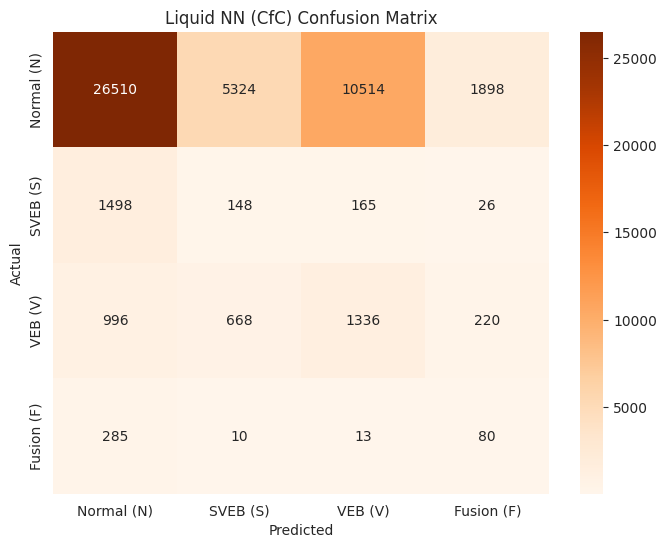

In [24]:
import time

liquid_model.eval()
y_pred_liquid, y_true_liquid = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        preds = torch.argmax(liquid_model(X_batch), dim=1)
        y_pred_liquid.extend(preds.cpu().numpy())
        y_true_liquid.extend(y_batch.numpy())

target_names = [inv_label_map[i] for i in range(len(unique_classes))]
print("\n--- Liquid NN (CfC + AutoNCP) Evaluation Report (DS2) ---")
print(classification_report(y_true_liquid, y_pred_liquid, target_names=target_names))

# --- deployability metrics (Pareto) ---
n_params = sum(p.numel() for p in liquid_model.parameters())

xb = next(iter(test_loader))[0].to(DEVICE)
with torch.no_grad():
    for _ in range(3): liquid_model(xb)                 # warm-up
    # FIXED: Check if CUDA is available before synchronizing
    if DEVICE.type == 'cuda' and torch.cuda.is_available():
        torch.cuda.synchronize()

    t = time.perf_counter()
    for _ in range(50): liquid_model(xb)

    if DEVICE.type == 'cuda' and torch.cuda.is_available():
        torch.cuda.synchronize()
    lat_ms = (time.perf_counter() - t) / 50 * 1000      # ms per batch

from sklearn.metrics import f1_score
results['Liquid NN'] = {
    'macro_f1': f1_score(y_true_liquid, y_pred_liquid, average='macro'),
    'params':   n_params,
    'lat_ms':   lat_ms,
}
print(f"Params: {n_params:,} | Latency: {lat_ms:.2f} ms/batch")

# Confusion matrix
cm_liquid = confusion_matrix(y_true_liquid, y_pred_liquid)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_liquid, annot=True, fmt='d', cmap='Oranges',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Liquid NN (CfC) Confusion Matrix'); plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.show()

### 6.1 Model Export for Local Inference

To perform real-time inference (e.g., using the signals captured via ESP32), we save the trained weights of our Liquid NN.

In [25]:
# Define the path to save the weights in Google Drive
WEIGHTS_PATH = os.path.join(DRIVE_PATH, 'liquid_nn_cfc_weights.pth')

# Save the state dictionary
torch.save(liquid_model.state_dict(), WEIGHTS_PATH)

print(f"Model weights successfully saved to: {WEIGHTS_PATH}")
print("You can now download this file for local inference.")

Model weights successfully saved to: /content/drive/MyDrive/ECG_Project/liquid_nn_cfc_weights.pth
You can now download this file for local inference.


## 7. Pareto Comparison

Now we compare the three models based on their Macro F1-Score (Performance) vs. Parameters (Complexity) and Latency (Efficiency).

,macro_f1,params,lat_ms
Random Forest,0.420388,48.0,31.755331
Bi-LSTM,0.220691,134148.0,0.468822
Liquid NN,0.248642,14676.0,183.304082


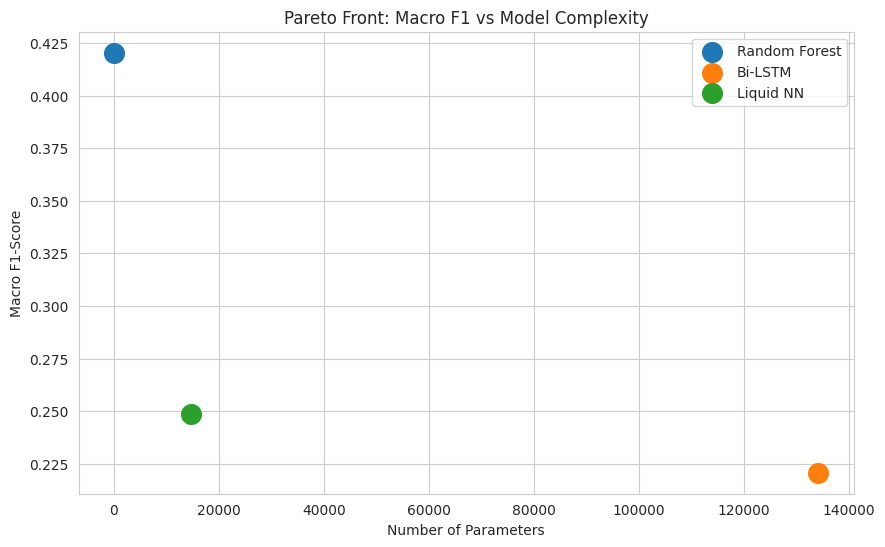

In [26]:
df_results = pd.DataFrame(results).T
display(df_results)

plt.figure(figsize=(10, 6))
for model_name in df_results.index:
    plt.scatter(df_results.loc[model_name, 'params'], df_results.loc[model_name, 'macro_f1'], s=200, label=model_name)

plt.title('Pareto Front: Macro F1 vs Model Complexity')
plt.xlabel('Number of Parameters')
plt.ylabel('Macro F1-Score')
plt.legend()
plt.grid(True)
plt.show()